<a href="https://colab.research.google.com/github/shivainlabs/Introduction-to-Deep-Learning-and-GenAI/blob/main/Week%2007/RNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
# memory
# sharing parameter -> Across timestep
# sequential data handling

In [13]:
# T1(h1)(x1)--W-->T2(h2)(x2)--W-->T3(h3)(x3)-->--W--->T30(h30)(x30)-->y=(31st day closing price)

In [14]:
# Tth timestep depends on all previous time step (that's why our sharing parameter exists)

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler

In [16]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Using device",device)


Using device cuda


In [17]:
def load_prices():
    '''Try real data via yfinance; fall back to synthetic on any failure.'''
    try:
        import yfinance as yf
        raw = yf.download("RELIANCE.NS", start="2015-01-01", end="2026-01-01",
                          interval='1d', auto_adjust=True, progress=False)
        if raw is None or len(raw) == 0:
            raise RuntimeError("empty download")

        if isinstance(raw.columns, pd.MultiIndex):
            raw.columns = raw.columns.get_level_values(0)
        raw = raw[["Open", "High", "Low", "Close", "Volume"]].dropna()
        print(f"Loaded REAL data for RELIANCE.NS: {len(raw)} rows "
              f"({raw.index.min().date()} -> {raw.index.max().date()}).")
        return raw
    except Exception as e:
        print("yfinance unavailable (", repr(e), ") -> using synthetic fallback.")
        return None


data_raw = load_prices()
data_raw.head()

Loaded REAL data for RELIANCE.NS: 2716 rows (2015-01-01 -> 2025-12-31).


Price,Open,High,Low,Close,Volume
Date,,,,,
2015-01-01,188.784586,189.998697,188.220116,189.125381,2963643
2015-01-02,189.167973,190.861356,188.358571,188.624817,7331366
2015-01-05,188.507649,189.764373,186.185911,186.558670,10103941
2015-01-06,185.312637,185.951642,177.218511,178.091827,18627980
2015-01-07,178.304858,182.927021,178.283559,181.968506,20720312


In [18]:
LOOKBACK = 30 # How many words we wanted to see for predicting the next word
HORIZON = 1 # for one prediction we want to do
# 30 previous days → next day's Close


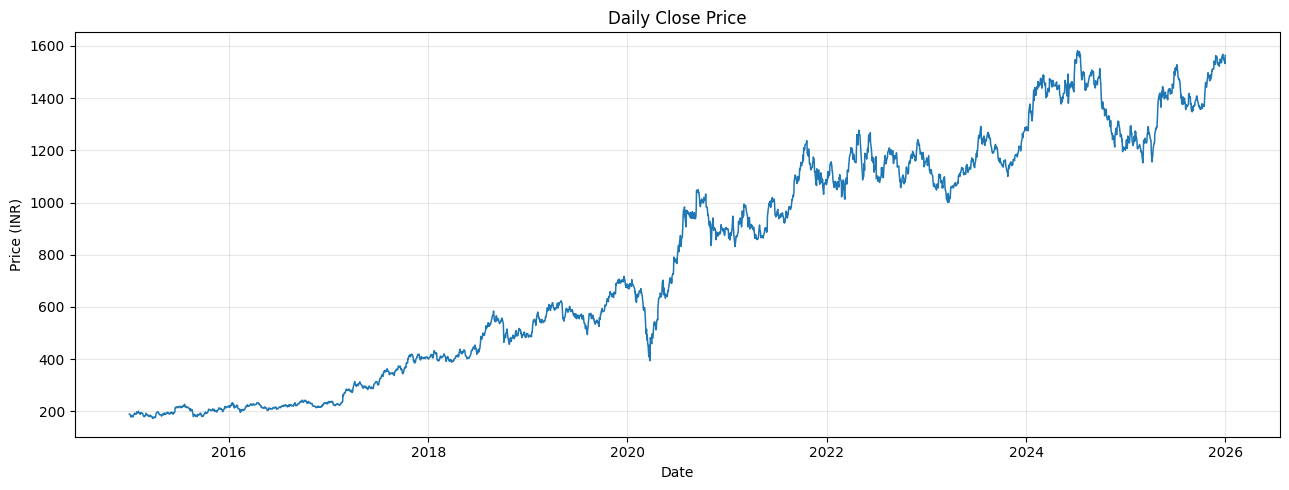

In [19]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(data_raw.index, data_raw["Close"], lw=1.1)
ax.set_title("Daily Close Price")
ax.set_xlabel("Date"); ax.set_ylabel("Price (INR)")
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [20]:
FEATURES = ['Open', "High", "Low"]
TARGET = 'Close'



In [21]:
# 1 -> [30,3], label = [1]

def make_windows(feature_matrix,target_vector,lookback):
  X,y = [],[]
  for i in range(lookback,len(feature_matrix)):
    X.append(feature_matrix[i-lookback:i])
    y.append(target_vector[i])
  return np.array(X,dtype=np.float32),np.array(y,dtype=np.float32)


In [27]:
feature_matrix = data_raw[FEATURES].values.astype(np.float32)
target_vector = data_raw[TARGET].values.astype(np.float32)

In [30]:
X_all,y_all = make_windows(feature_matrix,target_vector,LOOKBACK)
print("X_all shape:",X_all.shape)
print("y_all shape:",y_all.shape)

X_all shape: (2686, 30, 3)
y_all shape: (2686,)


In [31]:
X_all

array([[[ 188.78459,  189.9987 ,  188.22012],
        [ 189.16797,  190.86136,  188.35857],
        [ 188.50764,  189.76437,  186.18591],
        ...,
        [ 191.27672,  192.66122,  183.4595 ],
        [ 188.72066,  192.71448,  188.08165],
        [ 193.40672,  194.67409,  188.98691]],

       [[ 189.16797,  190.86136,  188.35857],
        [ 188.50764,  189.76437,  186.18591],
        [ 185.31264,  185.95164,  177.2185 ],
        ...,
        [ 188.72066,  192.71448,  188.08165],
        [ 193.40672,  194.67409,  188.98691],
        [ 194.68474,  196.13316,  193.63037]],

       [[ 188.50764,  189.76437,  186.18591],
        [ 185.31264,  185.95164,  177.2185 ],
        [ 178.30486,  182.92702,  178.28355],
        ...,
        [ 193.40672,  194.67409,  188.98691],
        [ 194.68474,  196.13316,  193.63037],
        [ 195.68587,  196.85739,  191.70271]],

       ...,

       [[1498.5712 , 1513.9004 , 1498.5712 ],
        [1513.9004 , 1516.6874 , 1504.5436 ],
        [1514.6965 , 1